# Homework 3 (due Friday, July 31st)
This assignment is designed to be practice outside of in-class lab.

There are only two problems this time. Do both for full credit. Reach out with any questions!

### Problem 1
There is a new data set in the `Datasets` folder on GitHub called `housing.csv`. This dataset is a collection of information on houses in the Portland/Vancouver area (if you plot the latitude and longitude you can see the outline of the coast!).
1. Load the `housing.csv` dataset from GitHub into your notebook (can be found: [here](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets))

2. Using `numpy`, built-in dataframe features, or functions you made in-lab, find the following for each column:
    - Median
    - Mean
    - Mode
    - Standard Deviation
    - Variance
    - Mean Absolute Deviation
3. Plot the `price` against `sqft_living`. Do you see a relationship?
4. Calculate the correlation between `price` against `sqft_living`. What does this value mean? Does it align with your answer to 3?
5. Perform linear regression on `price` against `sqft_living`. Plot the regression line and data on the same plot.
6. Compute your $R^2$ statistic for the regression line.

                       Mean        Median             Mode       Std Dev  \
bathrooms      3.282000e+00  3.250000e+00              3.5  9.015480e-01   
bedrooms       4.115000e+00  4.000000e+00              4.0  9.201204e-01   
condition      3.476000e+00  3.000000e+00              3.0  7.140966e-01   
date                    NaN           NaN  20140911T000000           NaN   
floors         1.826000e+00  2.000000e+00              2.0  4.888384e-01   
grade          9.968000e+00  1.000000e+01             10.0  1.186754e+00   
id             4.208925e+09  3.746251e+09     3528000040.0  2.843538e+09   
lat            4.761688e+01  4.762630e+01          47.6209  5.736079e-02   
long          -1.222301e+02 -1.222270e+02          -122.29  1.051631e-01   
price          1.740477e+06  1.531250e+06        1250000.0  6.673451e+05   
sqft_above     3.262938e+03  3.100000e+03           2610.0  1.156398e+03   
sqft_basement  7.439960e+02  7.200000e+02              0.0  7.245842e+02   
sqft_living 

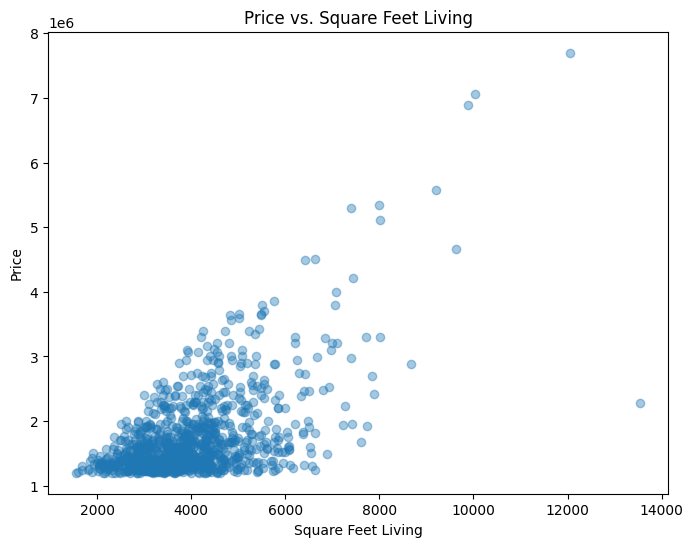

Correlation: 0.5794233888311131


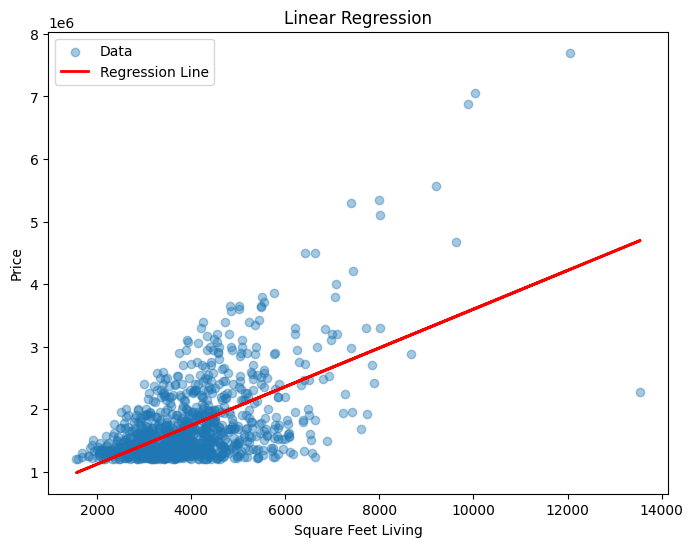

R^2 = 0.33573146352452987


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

housing = pd.read_csv("housing.csv")

stats = pd.DataFrame({
    "Mean": housing.mean(numeric_only=True),
    "Median": housing.median(numeric_only=True),
    "Mode": housing.mode().iloc[0],
    "Std Dev": housing.std(numeric_only=True),
    "Variance": housing.var(numeric_only=True),
    "Mean Abs Dev": housing.apply(
        lambda x: np.mean(np.abs(x - x.mean()))
        if np.issubdtype(x.dtype, np.number)
        else np.nan
    )
})

print(stats)

plt.figure(figsize=(8,6))
plt.scatter(housing["sqft_living"], housing["price"], alpha=0.4)

plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.title("Price vs. Square Feet Living")

plt.show()

corr = housing["price"].corr(housing["sqft_living"])

print("Correlation:", corr)

# Correlation is 0.57 which means there is a decent positive linear relationship between price and square feet living. Although there is a fair amount of scatter, as price increases so does square feet of living to some extent.

from sklearn.linear_model import LinearRegression

X = housing[["sqft_living"]]
y = housing["price"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.4, label="Data")
plt.plot(X, predictions, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.legend()

plt.show()

r2 = model.score(X, y)

print("R^2 =", r2)

# The R^2 value is approximately 0.33, meaning that about 33% of the variation in house price is explained by square footage alone. This is a alright relationship but many other factors could be at play here.

### Problem 2
Recall the following result we discussed in Week 5 Day 5 Lab:

- Let $A$ be a symmetric matrix ($A=A^T$). Let $R(A)=\frac{x^TAx}{x^Tx}$. Then, $\min\limits_{x\neq 0}R(A)=\lambda_{\min}(A)$ and $\max\limits_{x\neq 0}R(A)=\lambda_{\max}(A)$. Also, $x$'s that acheive these values are the eigenvectors.

Write a function that takes as an input a 2 by 2 matrix $A$, finds $\min\limits_{x\neq 0}R(A)$ and $\max\limits_{x\neq 0}R(A)$ using `scipy.optimize`, then outputs $|\lambda_{\min}(A)-\min\limits_{x\neq 0}R(A)|$ and $|\lambda_{\max}-\max\limits_{x\neq 0}R(A)|$ where the eigenvalues are calculated using `numpy`.

In [7]:
import numpy as np
from scipy.optimize import minimize

def compare_rayleigh(A):
    A = np.array(A)

    def R(x):
        x = np.array(x)
        return (x.T @ A @ x) / (x.T @ x)
    min_result = minimize(R, x0=[1, 1])

    max_result = minimize(lambda x: -R(x), x0=[1, 1])

    rayleigh_min = min_result.fun
    rayleigh_max = -max_result.fun

    eigenvalues = np.linalg.eigvals(A)
    lambda_min = np.min(eigenvalues)
    lambda_max = np.max(eigenvalues)
    
    min_error = abs(lambda_min - rayleigh_min)
    max_error = abs(lambda_max - rayleigh_max)

    print("Minimum eigenvalue:", lambda_min)
    print("Minimum Rayleigh quotient:", rayleigh_min)
    print("Error:", min_error)


    print("Maximum eigenvalue:", lambda_max)
    print("Maximum Rayleigh quotient:", rayleigh_max)
    print("Error:", max_error)

    return min_error, max_error

In [8]:
A = np.array([[2, 1],
              [1, 3]])

compare_rayleigh(A)

Minimum eigenvalue: 1.381966011250105
Minimum Rayleigh quotient: 1.3819660112859615
Error: 3.585642893710883e-11
Maximum eigenvalue: 3.618033988749895
Maximum Rayleigh quotient: 3.618033988749895
Error: 0.0


(np.float64(3.585642893710883e-11), np.float64(0.0))